In [18]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE=42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Imports and Set up Complete")

Imports and Set up Complete


In [19]:
# Neuron Calculation
# As a reminder, a neuron is the fundamental building block of our neural networks
# z = w1x1 + w2x2 + w3x3 + w...x... + b
# output = activation(z)

x = np.array([2.0, 1.0, 3.5])
w = np.array([.5, -1, 5])
b = 4.5

# Matrix Multipulcation (Dot Product)
# Dot product multiplies each value by its weight and sums

z = np.dot(x, w) + b
# Weighted Sum
print(z)

22.0


In [20]:
# After getting our weighted sum, we need to input it into an activation function
# Activation functions are called that because they mark when and how "active" a neuron is

# Common Activation functions
# Step function
# Looks like a stair step
def step(z):
  return np.where(z>=0, 1, 0)
  # If z is positive, return 1, else 0

# Sigmoid
# Used for probabilities (returns a value from zero to one)
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Tanh (Hyperbolic Tangent)
# This is used for values between -1 and 1, centered at zero
def tanh(z):
  return np.tanh(z)

# ReLU
# Rectified Linear Unit
# Similar to the step function
# If z is less than zero, return z, else return z
def relu(z):
  return np.maximum(0, z)

# Softmax
# Used for multiclass classification
# Gives you as many number as you need and they always sum to 1
# Interpreted as probability

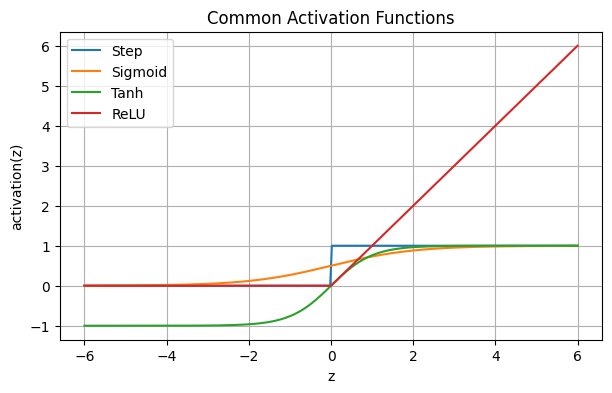

In [21]:
# Plot the activation functions for visibility
z_values = np.linspace(-6, 6, 300)

plt.figure(figsize=(7, 4))
plt.plot(z_values, step(z_values), label="Step")
plt.plot(z_values, sigmoid(z_values), label="Sigmoid")
plt.plot(z_values, tanh(z_values), label="Tanh")
plt.plot(z_values, relu(z_values), label="ReLU")

plt.title("Common Activation Functions")
plt.xlabel("z")
plt.ylabel("activation(z)")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Apply the activation function to the weighted sum from earlier, z
output = step(z) # z was 22.0 earlier
print(output)

1


In [23]:
def perceptron_predict(X, weights, bias):
  z = np.dot(X, weights) + bias
  # z = X @ weights + bias
  return step(z)

# We only have 4 possible inputs to consider for Logical OR and Logical AND
X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

In [24]:
# Logical AND Table
# 0 AND 0 -> 0
# 0 AND 1 -> 0
# 1 AND 0 -> 0
# 1 AND 1 -> 1

# Figure out some weights that work to represent this with the step function
# Goal is return 0 from step function is the expected output it zero

and_weights = np.array([1, 1])
and_bias = -1.5

and_predictions = perceptron_predict(X_logic, and_weights, and_bias)

for input, pred in zip (X_logic, and_predictions):
  print(input, "->", pred)

[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [25]:
# Logical OR Table
# 0 OR 0 -> 0
# 0 OR 1 -> 1
# 1 OR 0 -> 1
# 1 OR 1 -> 1

# Figure out some weights that work to represent this with the step function
# Goal is return 0 from step function is the expected output it zero

or_weights = np.array([1, 1])
or_bias = -.5

or_predictions = perceptron_predict(X_logic, or_weights, or_bias)

for input, pred in zip (X_logic, or_predictions):
  print(input, "->", pred)

[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [30]:
# Logical XOR (NOT A PERCEPTRON -> 3 Neurons)
# Input Layer
# Hidden Layer (With 2 Neurons)
# Output Layer (With 1 Neuron for 0 or 1)

hidden_weights = np.array([
    [1, -1], # Weights for x1 in Neuron1 and Neuron2
    [1, -1]  # Weights for x2 in Neuron1 and Neuron2
])

hidden_bias = np.array([-.5, 1.5]) # Bias for OR and then NAND

# First Neuron is calculating OR
# Second Neuron is calculating NAND
hidden_z = np.dot(X_logic, hidden_weights) + hidden_bias
hidden_output = step(hidden_z)


# Now we need to pass the output from the hidden layer as the input to the final
# layer, which is just AND
XOR_predict = perceptron_predict(hidden_output, and_weights, and_bias)

for input, middle_output, final_output in zip(X_logic, hidden_output, XOR_predict):
  print(input, "->", middle_output, "->", final_output)

[0 0] -> [0 1] -> 0
[0 1] -> [1 1] -> 1
[1 0] -> [1 1] -> 1
[1 1] -> [1 0] -> 0


In [46]:
# Let's do one more perceptron
# We'll do this with the same example we've been using
# Two inputs and one output (perceptron)
# Hours Studied and Quiz Average
# Pass/Fail

# List of students, each has 2 inputs or features
X = np.array([
    [1, 50],
    [2, 55],
    [3, 65],
    [4, 70],
    [5, 80],
    [6, 85],
    [7, 90]
])

# Supervised Learning because we have outputs
y = np.array([0, 0, 0, 1, 1, 1, 1])

# Initialize our weights and bias
# Normally we would randomize, to keep it simple, let's just use zero
weights = np.zeros(2)
bias = 0.0

# This is different than what we did before because I want to TRAIN these
# weights

# Hyperparameters are parameters for your model that you configure
# Learning rate
# Epochs
# Number of layers
# Number of nodes per layer

learning_rate = .01 # Determines how fast we learn from the data
epochs = 200 # An Epoch is one full pass of the data

# Let's train our model
for epoch in range(epochs):

  # Total Errors to see when the model stops improving
  total_errors = 0

  # We'll go through each prediction in our perceptron. We'll check if a value
  # is correct, we'll then update the weight if the prediction is wrong

  for xi, actual in zip(X, y):
    z = np.dot(xi, weights) + bias
    prediction = step(z)

    # Calculate the error to update our weight
    # We do this with some sort of loss function
    # Tells us how far we are from our result

    error = actual-prediction

    # Update our weights
    # We'll update the weights based off of xi
    # We'll update the bias without xi since it is shared
    weights = weights + learning_rate * error * xi
    bias = bias + learning_rate*error

    total_errors += abs(error)

    # print(
    #     f"Epoch {epoch + 1} "
    #     f"Weights: {weights}"
    #     f"Bias: {bias}"
    #     f"Total Errors to this point: {total_errors}"
    # )

print(f"Final Weights: {weights}")
print(f"Final Bias: {bias}")

Final Weights: [ 1.12 -0.05]
Final Bias: -0.18000000000000002


In [47]:
# Let's create some test students

X_test = np.array([
    [1, 35], # Low Time, Low Score -> 0
    [6, 95], # High time, High score -> 1
    [2, 80], # Mixed, who knows?
    [7, 30],
    [1, 50] # Should be 0
])

# Now we can use perceptron predict
pass_predictions = perceptron_predict(X_test, weights, bias)

for x, pred in zip(X_test, pass_predictions):
  print(x, "->", pred)

[ 1 35] -> 0
[ 6 95] -> 1
[ 2 80] -> 0
[ 7 30] -> 1
[ 1 50] -> 0
